In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
from zipfile import ZipFile
import io


def read_series(path):
    text = Path(path).read_text(encoding="utf-8", errors="ignore")
    text = text.replace(";", ",")
    values = pd.read_csv(io.StringIO(text), sep=",", header=None).values
    values = np.asarray(values, dtype=float)

    if values.ndim > 1:
        if values.shape[0] == 1 or values.shape[1] == 1:
            values = values.ravel()
        else:
            values = values[:, 0]

    values = values[np.isfinite(values)]
    return values


def extract_timesets():
    archive_path = next(Path(".").glob("**/TimeSets.zip"), None)

    if archive_path is None:
        return

    with ZipFile(archive_path) as z:
        z.extractall("data/TimeSets")


timesets_path = Path("data/TimeSets")

if not timesets_path.exists():
    extract_timesets()

if not timesets_path.exists():
    raise FileNotFoundError("Положи TimeSets в data/TimeSets или TimeSets.zip в корень проекта/data")

series = {
    "S2": read_series(timesets_path / "S2.txt"),
    "S6": read_series(timesets_path / "S6.txt"),
    "Lorenz1": read_series(timesets_path / "Lorenz1.txt"),
}

for name, values in series.items():
    print(f"{name}: длина = {len(values)}, min = {values.min():.4f}, max = {values.max():.4f}")


S2: длина = 100000, min = -3.4640, max = 3.9484
S6: длина = 100000, min = 0.0951, max = 0.9750
Lorenz1: длина = 100000, min = -20.5120, max = 21.1330


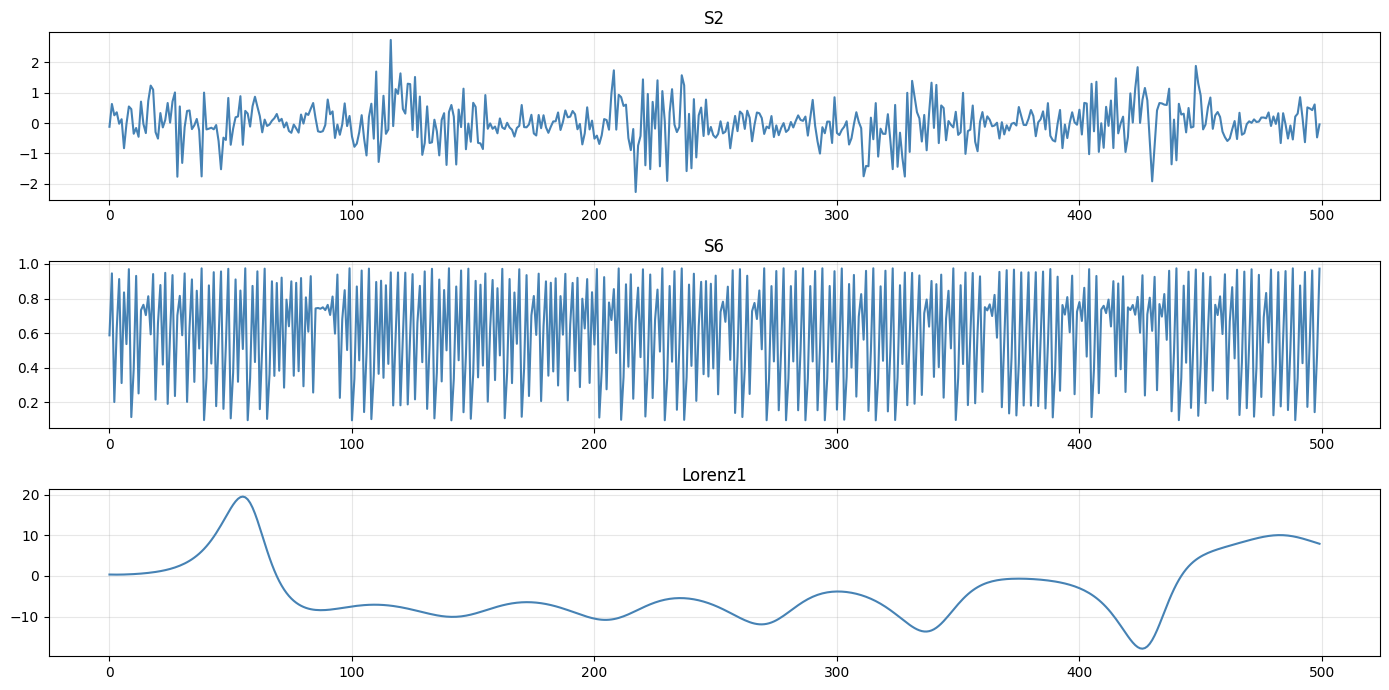

In [5]:
plt.figure(figsize=(14, 7))

for i, (name, values) in enumerate(series.items(), start=1):
    plt.subplot(3, 1, i)
    plt.plot(values[:500], color="steelblue")
    plt.title(name)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
def choose_tau(x, max_lag=200):
    x = (x - np.mean(x)) / np.std(x)

    for lag in range(1, max_lag + 1):
        corr = np.corrcoef(x[:-lag], x[lag:])[0, 1]

        if corr < 1 / np.e:
            return lag

    return 1


def embedding(x, dim, tau=1):
    n = len(x) - (dim - 1) * tau
    return np.column_stack([x[i * tau:i * tau + n] for i in range(dim)])


def fnn_percent(x, max_dim=10, tau=1, rtol=10, atol=2):
    x = (x - np.mean(x)) / np.std(x)
    result = []

    for dim in range(1, max_dim + 1):
        emb = embedding(x, dim, tau)
        emb_next = embedding(x, dim + 1, tau)
        emb = emb[:len(emb_next)]

        nn = NearestNeighbors(n_neighbors=2).fit(emb)
        distances, indexes = nn.kneighbors(emb)

        r_m = distances[:, 1]
        nearest = indexes[:, 1]
        extra = np.abs(emb_next[:, -1] - emb_next[nearest, -1])
        r_next = np.sqrt(r_m ** 2 + extra ** 2)

        false_1 = extra / (r_m + 1e-10) > rtol
        false_2 = r_next / np.std(x) > atol
        false_neighbors = false_1 | false_2

        result.append(false_neighbors.mean() * 100)

    return np.array(result)


In [7]:
max_dim = 10
fnn_results = {}
taus = {}

for name, values in series.items():
    values = values[:5000]
    tau = choose_tau(values)
    taus[name] = tau
    fnn_results[name] = fnn_percent(values, max_dim=max_dim, tau=tau)

    min_dim = np.argmax(fnn_results[name] < 1) + 1
    if fnn_results[name][min_dim - 1] >= 1:
        min_dim = max_dim

    print(f"{name}: tau = {tau}, минимальная размерность вложения = {min_dim}")
    print(np.round(fnn_results[name], 2))


S2: tau = 1, минимальная размерность вложения = 10
[98.36 80.11 37.84 19.68 17.98 19.58 23.61 28.77 34.5  40.38]
S6: tau = 1, минимальная размерность вложения = 2
[4.02 0.86 0.42 0.18 0.16 0.1  0.04 0.04 0.02 0.02]
Lorenz1: tau = 31, минимальная размерность вложения = 4
[95.29 36.7   1.08  0.    0.    0.    0.    0.    0.    0.  ]


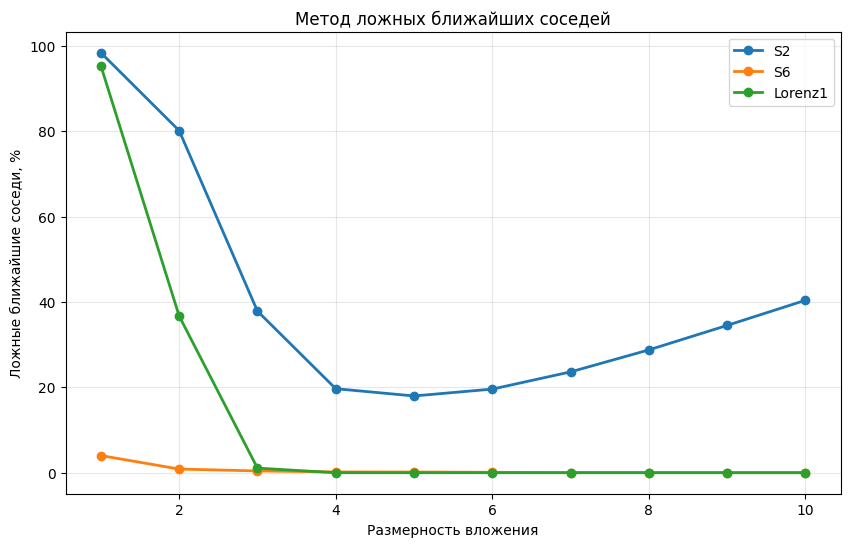

In [8]:
dims = np.arange(1, max_dim + 1)

plt.figure(figsize=(10, 6))

for name, values in fnn_results.items():
    plt.plot(dims, values, marker="o", linewidth=2, label=name)

plt.xlabel("Размерность вложения")
plt.ylabel("Ложные ближайшие соседи, %")
plt.title("Метод ложных ближайших соседей")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Выводы

Минимальную размерность выбираем в первой точке, где доля ложных ближайших соседей становится меньше 1%.

На реальных данных получились такие значения:

S2: tau = 1, минимальная размерность = 10. Ряд похож на модулированный шум, поэтому доля ложных соседей не падает до малого значения.

S6: tau = 1, минимальная размерность = 2. Для логистического отображения достаточно малой размерности вложения.

Lorenz1: tau = 31, минимальная размерность = 4. Для ряда Лоренца нужна большая размерность, потому что восстанавливается скрытая динамика аттрактора по одной координате.
